In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftshift
from scipy.interpolate import interp1d
import hapi as hp

In [15]:
tau = 50e-15  #сдлительность импульса
lambda0 = 5e-6  # центральная длина волны
c = 299792458
w0 = 2 * np.pi * c / lambda0  # несущая частота
dt = 1e-15  #шаг по времени
T = 10e-12  # полуширина окна
t = np.arange(-T, T + dt, dt)

df = 1 / (2 * T)  #Гц шаг по частоте
F = 1 / (2 * dt)  #Гц макс. частота
f = np.arange(-F, F + df, df)

#xастотное окно
f1 = 5.8e13
f2 = 6.1e13
f_width = 0.05e13
delay_maх = 10000

temperature = 296.0  # K (23 °C)
pressure = 1.0  #атм, общее давление
relative_humidity = 24
# Давление насыщенного пара при 23°C ~ 0.0276 атм
p_sat = 0.0276  #атм
path_l = 300.0  #длина пути в среде, см
p_ref = 1.0

In [16]:
hp.db_begin('hitran_ata')
nu_min = 1500.0  # см^-1   ~ 6.67 мкм
nu_max = 2500.0  # см^-1   ~ 4.0 мкм

hp.fetch('H2O', 1, 1, nu_min, nu_max)

# Коэффициент поглощения k(nu) в см^-1 при заданных p, T
# В Environment задаём общее давление, в Diluent — состав газа
nu_hitran, k_ref = hp.absorptionCoefficient_Lorentz(
    SourceTables='H2O',
    Environment={'p': p_ref, 'T': temperature},
    Diluent={'air': 1.0, 'self': 0.0},
    WavenumberRange=[nu_min, nu_max],
    WavenumberStep=0.01,
    HITRAN_units=False
)
p_h2o = (relative_humidity / 100.0) * p_sat
k_hitran = k_ref *(p_h2o/ p_ref)
tr_h = np.exp(-k_hitran * path_l)
f_cm1 = f / c * 1e-2

interp_T = interp1d(
    nu_hitran,
    tr_h,
    kind='linear',
    bounds_error=False,
    fill_value=1.0  #вне дапазона считаем нет поглощения
)

# Пропускание на частотной сетке сигнала
T_on_f_grid = interp_T(f_cm1)

Using hitran_ata

H2O
                     Lines parsed: 9231

Data is fetched from http://hitran.org

BEGIN DOWNLOAD: H2O
  65536 bytes written to hitran_ata/H2O.data
  65536 bytes written to hitran_ata/H2O.data
  65536 bytes written to hitran_ata/H2O.data
  65536 bytes written to hitran_ata/H2O.data
  65536 bytes written to hitran_ata/H2O.data
  65536 bytes written to hitran_ata/H2O.data
  65536 bytes written to hitran_ata/H2O.data
  65536 bytes written to hitran_ata/H2O.data
  65536 bytes written to hitran_ata/H2O.data
  65536 bytes written to hitran_ata/H2O.data
  65536 bytes written to hitran_ata/H2O.data
  65536 bytes written to hitran_ata/H2O.data
  65536 bytes written to hitran_ata/H2O.data
  65536 bytes written to hitran_ata/H2O.data
  65536 bytes written to hitran_ata/H2O.data
  65536 bytes written to hitran_ata/H2O.data
  65536 bytes written to hitran_ata/H2O.data
  65536 bytes written to hitran_ata/H2O.data
  65536 bytes written to hitran_ata/H2O.data
  65536 bytes written 

In [17]:
f_min = 5e13
f_max = 7e13
f_min_idx = np.argmin(np.abs(f - f_min)) #ищем самое близкое значение
f_max_idx = np.argmin(np.abs(f - f_max))

delays = np.arange(0, delay_maх) * 1e-15
res_spec = []

for delay in delays:
    pulse1 = np.exp(-t ** 2 / (2 * tau ** 2)) * np.sin(w0 * t)
    pulse2 = np.exp(-(t - delay) ** 2 / (2 * tau ** 2)) * np.sin(w0 * (t - delay))
    pulse = pulse1 + pulse2

    spec = fftshift(fft(pulse))
    spec_intensity = np.abs(spec) ** 2
    spec_slice = spec_intensity[f_min_idx:f_max_idx] * T_on_f_grid[f_min_idx:f_max_idx]

    res_spec.append(spec_slice)

res_spec = np.array(res_spec)  # shape: (len(delays), N_freq)


In [18]:
df_delay = 1 / (delays[-1] - delays[0])
F_delay = 1 / (2 * (delays[1] - delays[0]))
f_delay = np.arange(-F_delay, F_delay, df_delay)

f_min_delay_idx = np.argmin(np.abs(f_delay - 5e13)) #ищем самое близкое значение
f_max_delay_idx = np.argmin(np.abs(f_delay - 7e13))

res_spec2d = []
for k in range(res_spec.shape[1]):
    spec_delay = fftshift(fft(res_spec[:, k]))
    spec_delay_slice = np.abs(spec_delay[f_min_delay_idx:f_max_delay_idx]) ** 2
    res_spec2d.append(spec_delay_slice)

res_spec2d = np.array(res_spec2d).T  # (freq_delay, freq)

TypeError: imsave() missing 1 required positional argument: 'arr'

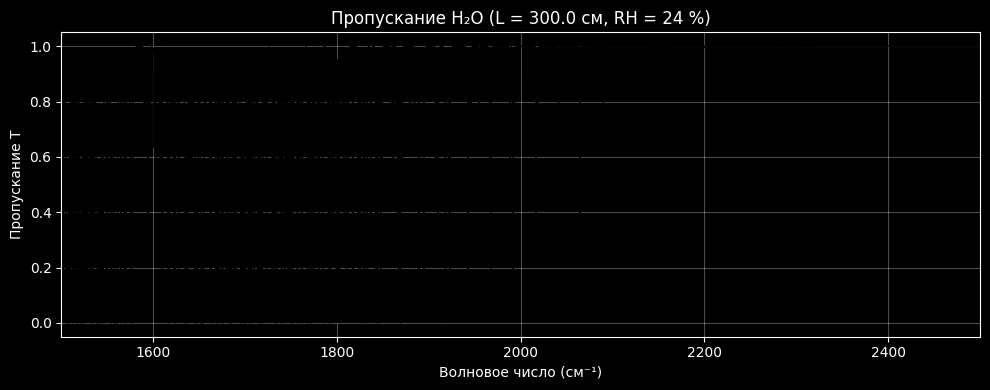

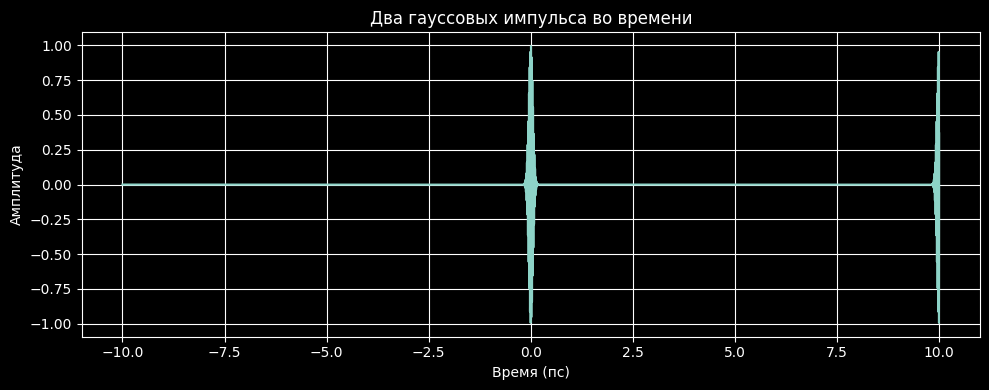

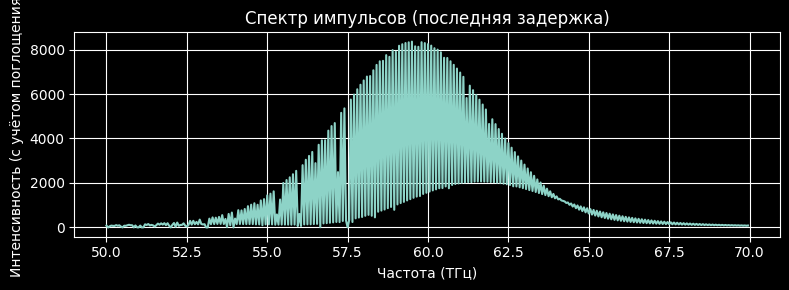

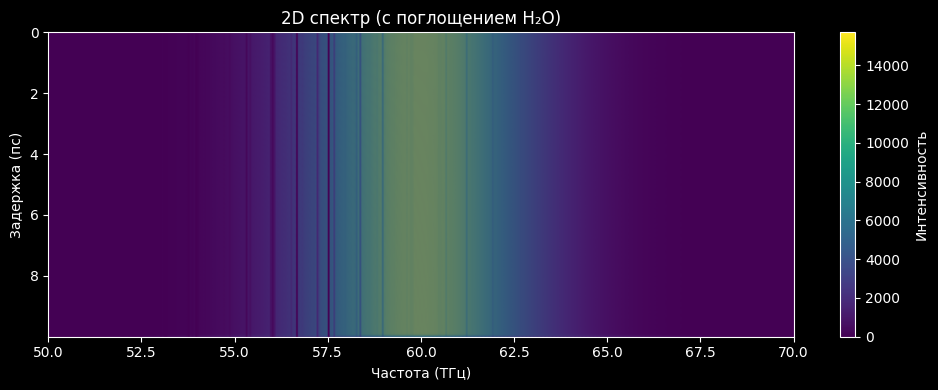

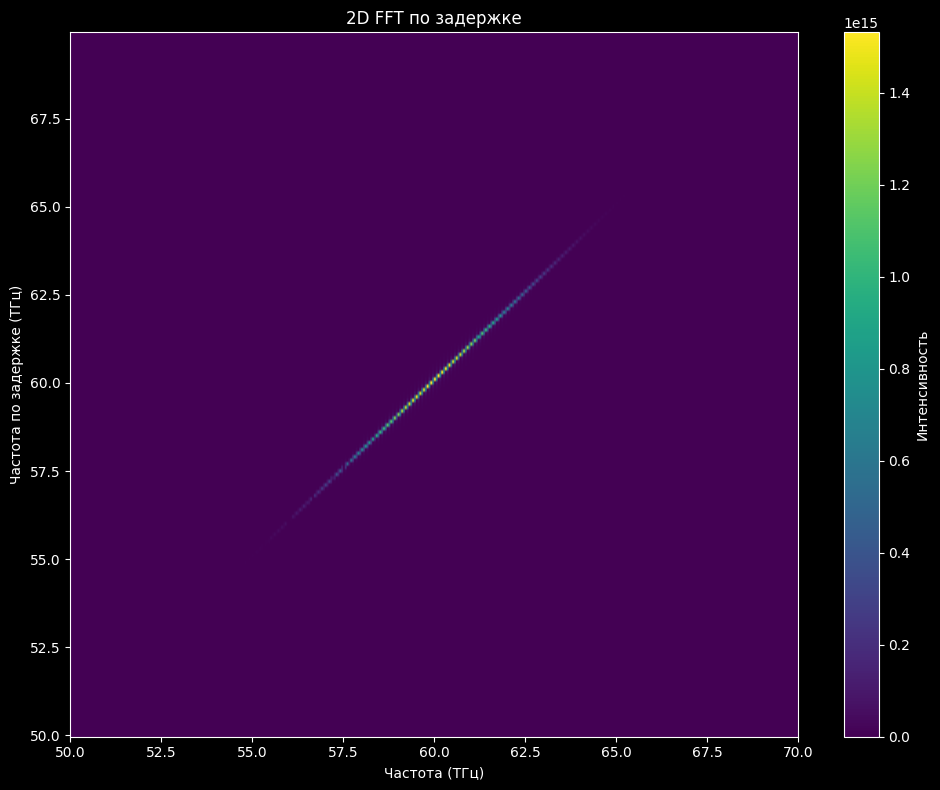

In [21]:
plt.figure(figsize=(10, 4), edgecolor='white')
plt.plot(nu_hitran, tr_h, 'k-', linewidth=1.0)
plt.xlabel('Волновое число (см⁻¹)')
plt.ylabel('Пропускание T')
plt.title(f'Пропускание H₂O (L = {path_l} см, RH = {relative_humidity:.0f} %)')
plt.grid(True, alpha=0.3)
plt.xlim(nu_min, nu_max)
plt.pcolor
plt.tight_layout()


plt.figure(figsize=(10, 4))
plt.plot(t * 1e12, pulse)
plt.xlabel('Время (пс)')
plt.ylabel('Амплитуда')
plt.title('Два гауссовых импульса во времени')
plt.grid(True)
plt.tight_layout()

# Одномерный спектр для последнего delay
plt.figure(figsize=(8, 3))
plt.plot(f[f_min_idx:f_max_idx] * 1e-12, res_spec[-1])
plt.xlabel('Частота (ТГц)')
plt.ylabel('Интенсивность (с учётом поглощения)')
plt.title('Спектр импульсов (последняя задержка)')
plt.grid(True)
plt.tight_layout()

# 2D по delay–frequency
plt.figure(figsize=(10, 4))
plt.imshow(res_spec,
           extent=[f[f_min_idx] * 1e-12, f[f_max_idx] * 1e-12, delays[-1] * 1e12, delays[0] * 1e12],
           aspect='auto',
           cmap='viridis')
plt.xlabel('Частота (ТГц)')
plt.ylabel('Задержка (пс)')
plt.title('2D спектр (с поглощением H₂O)')
plt.colorbar(label='Интенсивность')
plt.tight_layout()

plt.figure(figsize=(10, 8))
plt.imshow(res_spec2d,
           extent=[f[f_min_idx] * 1e-12,
                   f[f_max_idx] * 1e-12,
                   f_delay[f_min_delay_idx] * 1e-12,
                   f_delay[f_max_delay_idx] * 1e-12],
           aspect='auto',
           cmap='viridis',
           origin='lower')
plt.xlabel('Частота (ТГц)')
plt.ylabel('Частота по задержке (ТГц)')
plt.title('2D FFT по задержке')
plt.colorbar(label='Интенсивность')
plt.tight_layout()
plt.imsave("
plt.show()


In [20]:
import numpy as np

def nonuniform_fourier_integral(t, f_t, omega):
    t = np.asarray(t)
    f_t = np.asarray(f_t)
    omega = np.asarray(omega)

    # веса по неравномерной сетке (простейший вариант – кусочно-линейная аппроксимация)
    dt = np.empty_like(t)
    dt[1:-1] = 0.5 * (t[2:] - t[:-2])       # средний шаг вокруг точки
    dt[0] = t[1] - t[0]
    dt[-1] = t[-1] - t[-2]

    # матричное вычисление сумм: F_j = sum_k f_k * exp(-i * w_j * t_k) * dt_k
    phase = np.exp(-1j * np.outer(omega, t))  # shape: (M_omega, N_t)
    F = phase @ (f_t * dt)                   # матричное произведение

    return F
